## Preliminary BNN results April 1st

Theory reference:

Code reference: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/DL2/Bayesian_Neural_Networks/dl2_bnn_tut1_students_with_answers.html

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange

### 1. dataset

The demo dataset used here, `AA_numerical_features.csv`, has one text feature `Date` and five numerical features `Open`, `High`, `Low`, `Close`, `Volume`. The Bayesian going to be proposed takes the numerical features except `Close` as iputs and outputs "Close" as stock closing price prediction.

In [14]:
# read data from csv file and drop the date
df = pd.read_csv("AA_numerical_features.csv")
df = df.drop("Date", axis=1)

In [15]:
df.head()

,Open,High,Low,Close,Volume
0,36.118550,36.708424,35.732863,36.390800,9425427
1,36.254680,36.685743,35.347178,35.460617,7654973
2,35.460612,35.687487,34.280859,34.394299,8445526
3,34.076680,34.689245,33.690994,33.736366,7967000
4,34.167420,34.689235,33.804420,33.872482,10707532


In [16]:
# choose "Close" column as target and the other columns as inputs
x = df.drop("Close", axis=1)
y = df["Close"]

Before training the network using the dataset, the numerical features should first be standardized. Different from traditional ML learning approaches, the dataset doesn't need to be splitted into training and testing in BNN.

In [17]:
# standardize the data
scaler = StandardScaler()
x_scalered = scaler.fit_transform(x)

# convert features and labels to PyTorch tensors
x_scalered = torch.from_numpy(x_scalered).float()
y = torch.from_numpy(y.to_numpy()).float()

Take a look at the features `x_scalered` and the labels `y`.

In [18]:
x_scalered.shape, y.shape

(torch.Size([1383, 4]), torch.Size([1383]))

### 2. BNN setup

Choose the fully connected neural network as the functional model. Choose the Gaussian distribution as the prior of parameters and the likelihood function.

In [19]:
class BNN(PyroModule):
    def __init__(self, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5, prior_scale=5.):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., prior_scale);
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., prior_scale * np.sqrt(2 / self.layer_sizes[layer_idx])).expand(
                [self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., prior_scale).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

Function to visualize the predictions and the uncertainty of predictions.

In [38]:
def plot_predictions(preds, y):
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

Function to visualize only the uncertainty.

In [47]:
def plot_uncertainty(preds, y):
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

### 3. variational inference

In [53]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(in_dim=4, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [54]:
num_epochs = 25000 # number of training epoches
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

for epoch in progress_bar:
    loss = svi.step(x_scalered, y)
    progress_bar.set_postfix(loss=f"{loss / x_scalered.shape[0]:.3f}")
    if epoch % 1000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / x_scalered.shape[0]))

  0%|          | 14/25000 [00:00<05:49, 71.53it/s, loss=5757205.762]

[iteration 0001] loss: 4045479.084


  4%|▍         | 1010/25000 [00:10<04:23, 90.93it/s, loss=11790.331] 

[iteration 1001] loss: 19250.392


  8%|▊         | 2010/25000 [00:21<03:56, 97.36it/s, loss=13415.117] 

...

 92%|█████████▏| 23017/25000 [07:46<00:20, 96.29it/s, loss=3.829] 

[iteration 23001] loss: 2.763


 96%|█████████▌| 24017/25000 [07:57<00:10, 97.17it/s, loss=2.819] 

[iteration 24001] loss: 3.239


100%|██████████| 25000/25000 [08:07<00:00, 51.32it/s, loss=2.423]


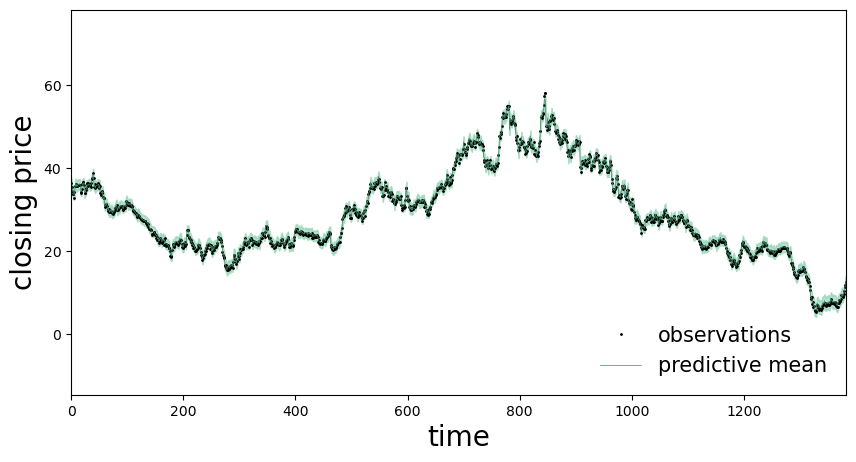

In [57]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(x_scalered)

plot_predictions(preds, y)

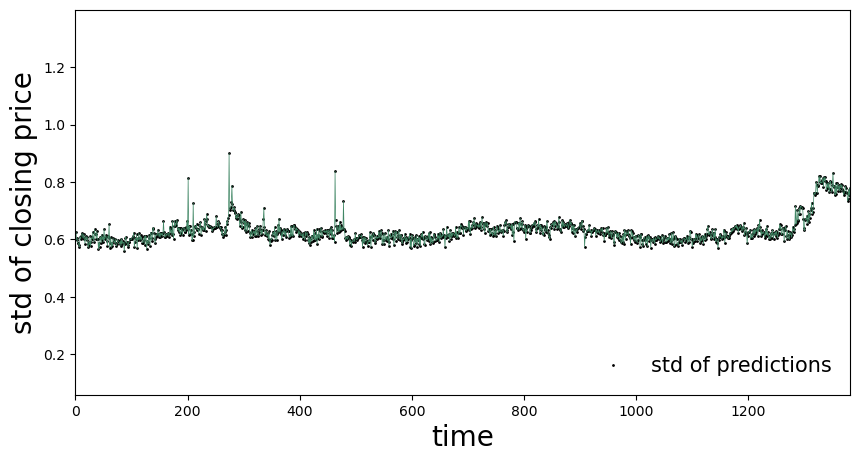

In [58]:
plot_uncertainty(preds, y)